# XGBoost

### Import needed libraries

In [40]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb


### Initialize dataframes with aggregate data

In [41]:
phy30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_30s.csv', encoding="utf-8-sig")
phy16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_16s.csv', encoding="utf-8-sig")
phy10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_10s.csv', encoding="utf-8-sig")
scada30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_30s.csv', encoding="utf-8-sig")
scada16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_16s.csv', encoding="utf-8-sig")
scada10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_10s.csv', encoding="utf-8-sig")

phy30sdf.head()


,bucket,system_id,prop_key,asset_id,avg_value,max_value,min_value,num_measurements,num_attacks,attack_types
0,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_1,31.8,178.0,0.0,10,0,['normal']
1,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_2,0.0,0.0,0.0,10,0,['normal']
2,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_3,0.0,0.0,0.0,10,0,['normal']
3,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_4,0.0,0.0,0.0,10,0,['normal']
4,2021-04-09 11:30:30+00:00,testbed_system_1,pressure,testbed_system_1_Tank_Tank_5,0.0,0.0,0.0,10,0,['normal']


### Extract feature and target arrays

In [42]:
X, y = phy30sdf.drop('num_attacks', axis=1), phy30sdf[['num_attacks']]

### Convert text features to categories

In [43]:
phy30sdf = X.select_dtypes(exclude=np.number).columns.tolist()

for col in phy30sdf:
   X[col] = X[col].astype('category')

### Split the data

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [45]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [46]:
# Define hyperparameters
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [47]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [48]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect CV results object

In [49]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0         7.437103        0.014851        7.437597       0.059508
1         5.211462        0.010317        5.211367       0.042652
2         3.652124        0.007226        3.652219       0.029238
3         2.559126        0.005048        2.559032       0.020469
4         1.793288        0.003572        1.792770       0.015007


### Y_test may be a DataFrame with one column; convert to 1d array

In [50]:
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
mse = mean_squared_error(y_test_arr, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, preds)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}')

MSE: 0.0000, RMSE: 0.0000, R^2: 1.0000


### predicted vs actual scatter

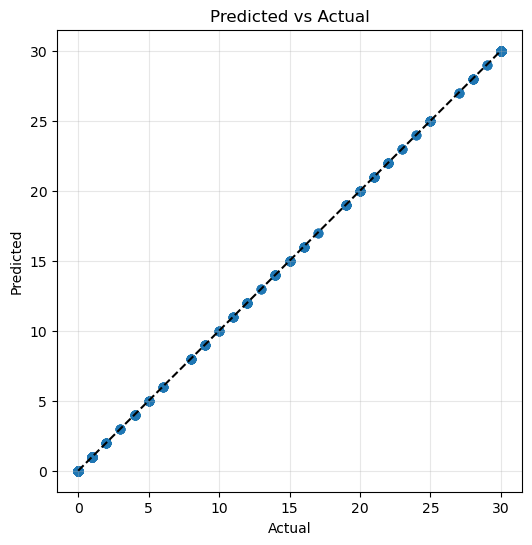

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_arr, preds, alpha=0.5)
lims = [min(y_test_arr.min(), preds.min()), max(y_test_arr.max(), preds.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()